## Imports

In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from collections import Counter
import random

In [4]:
import torch
from torch import optim
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

In [5]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## Configs

### cuda Check

In [7]:
print("PyTorch version:", torch.__version__)
cudaAvailable = torch.cuda.is_available()
print("CUDA available:", cudaAvailable)
if cudaAvailable:
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version (PyTorch):", torch.version.cuda)
    print("cuDNN version:", torch.backends.cudnn.version())

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA version (PyTorch): 12.6
cuDNN version: 91002


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
device

device(type='cuda')

### Data

In [10]:
data_dir = "dataset/"
img_size = 128
batch_size = 16
seq_len = 3    
train_split = 0.8    

### ProgNet Paramaters

In [11]:
feature_dim = 512
hidden_dim = 256
num_layers = 2
dropout = 0.3

### Training Parameters

In [12]:
epochs = 20
learning_rate = 0.001
weight_decay = 1e-4
scheduler_type = "cosine"
label_smoothing = 0.05

### Saving the Model

In [13]:
seed = 42
torch.manual_seed(seed)
random.seed(seed)

save_path = "cane_sight.pth"

### Transform

In [14]:
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

## Loading Image Data

### Sequential Wrapper of Dataset

In [15]:
class SequenceDataset(Dataset):
    def __init__(self, root, transform, seq_len=3):
        self.dataset = datasets.ImageFolder(root=root, transform=transform)
        self.classes = self.dataset.classes
        self.seq_len = seq_len
        self.class_to_idx = self.dataset.class_to_idx

        # Group images by class
        self.class_to_images = {}
        for idx, (path, label) in enumerate(self.dataset.samples):
            if label not in self.class_to_images:
                self.class_to_images[label] = []
            self.class_to_images[label].append(idx)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # pick main sample
        img, label = self.dataset[idx]

        # sample extra images from the same class
        choices = random.choices(self.class_to_images[label], k=self.seq_len-1)
        imgs = [img] + [self.dataset[i][0] for i in choices]

        # stack into (seq_len, C, H, W)
        imgs = torch.stack(imgs, dim=0)
        return imgs, label

### Load Data

In [16]:
dataset = SequenceDataset(root=data_dir, transform=transform, seq_len=seq_len)
class_names = dataset.classes
num_classes = len(class_names)

### Train and Test Split

In [17]:
train_size = int(train_split * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [18]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [19]:
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Classes: ['BacterialBlights', 'Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']
Train: 15940 | Test: 3986


## Distribution of Images

### Class-Wise Distribution

In [20]:
class_counts = Counter(dataset.dataset.targets)
classes = dataset.classes

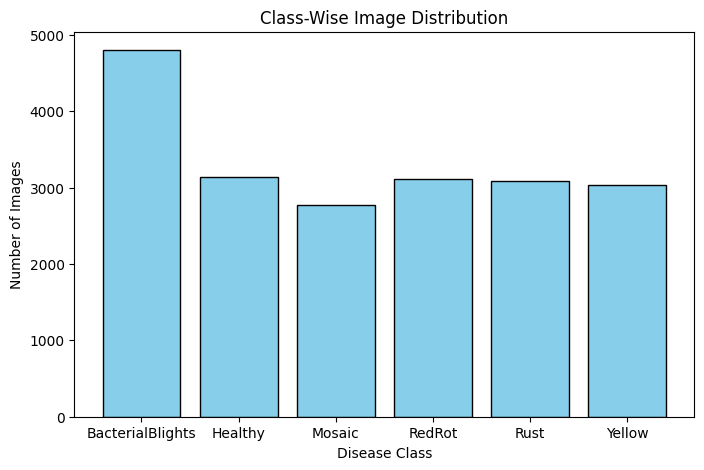

In [21]:
counts = [class_counts[i] for i in range(len(classes))]

plt.figure(figsize=(8,5))
plt.bar(classes, counts, color="skyblue", edgecolor="black")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Class-Wise Image Distribution")
plt.show()

### Class-Wise Train-Test Distribution

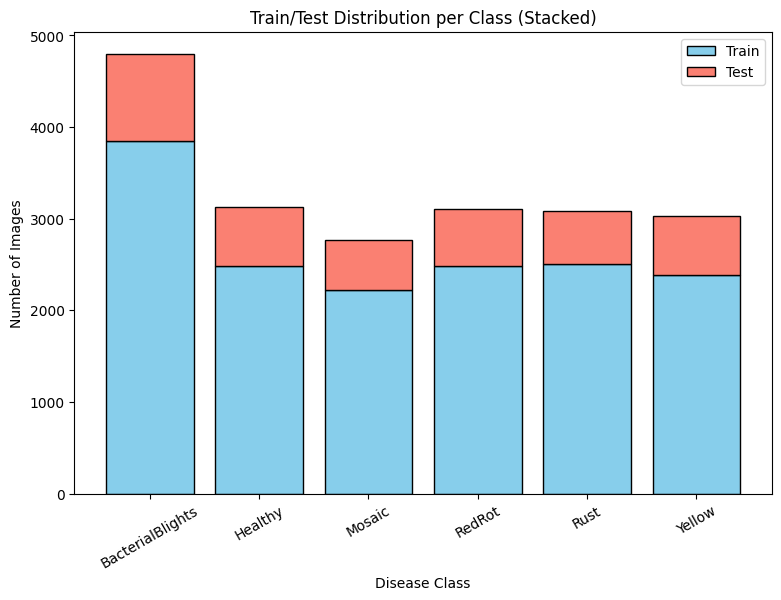

In [22]:
train_counts = Counter([dataset.dataset.targets[i] for i in train_dataset.indices])
test_counts  = Counter([dataset.dataset.targets[i] for i in test_dataset.indices])

train_vals = [train_counts[i] for i in range(len(classes))]
test_vals  = [test_counts[i] for i in range(len(classes))]

x = range(len(classes))
plt.figure(figsize=(9,6))
plt.bar(x, train_vals, label="Train", color="skyblue", edgecolor="black")
plt.bar(x, test_vals, bottom=train_vals, label="Test", color="salmon", edgecolor="black")

plt.xticks(x, classes, rotation=30)
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Train/Test Distribution per Class (Stacked)")
plt.legend()
plt.show()

### Image Distribution Summary

In [23]:
for image_class, count in class_counts.items():
    print(f"{dataset.classes[image_class]}: {count}")

print(f"\nTotal images: {len(dataset)}")

BacterialBlights: 4800
Healthy: 3132
Mosaic: 2772
RedRot: 3108
Rust: 3084
Yellow: 3030

Total images: 19926


## Model

### SymNet - CNN Symptom Feature Extractor

In [24]:
def conv_block(cin, cout, k=3, s=1, p=1):
    return nn.Sequential(
        nn.Conv2d(cin, cout, kernel_size=k, stride=s, padding=p, bias=False),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
    )

In [25]:
class SymNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2),
        )
        self.stage2 = nn.Sequential(
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2),
        )
        self.stage3 = nn.Sequential(
            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2),
        )
        self.stage4 = nn.Sequential(
            conv_block(128, 256),
            conv_block(256, 256),
            nn.MaxPool2d(2),
        )
        self.stage5 = nn.Sequential(
            conv_block(256, 512),
            conv_block(512, 512),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        return x.view(x.size(0), -1) 

### ProgNet - LSTM Sequence Modeler

In [26]:
class ProgNet(nn.Module):
    def __init__(self, feature_dim=feature_dim, hidden_dim=hidden_dim, num_layers=num_layers,
                 num_classes=num_classes, dropout=dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_hidden = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.fc(last_hidden)

### CaneSight - SymNet + ProgNet

In [27]:
class CaneSight(nn.Module):
    def __init__(self, symnet, prognet):
        super().__init__()
        self.symnet = symnet
        self.prognet = prognet

    def forward(self, x_seq):
        batch_size, seq_len, C, H, W = x_seq.size()
        features = []

        for t in range(seq_len):
            img = x_seq[:, t, :, :, :]
            feat = self.symnet(img)
            features.append(feat)

        features = torch.stack(features, dim=1)
        return self.prognet(features)

## Training

In [28]:
symnet = SymNet()
prognet = ProgNet()
model = CaneSight(symnet, prognet).to(device)

In [29]:
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [30]:
if scheduler_type == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
elif scheduler_type == "step":
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
else:
    scheduler = None

### Training Function

In [31]:
def train_one_epoch(loader):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, total_correct/total

### Testing Function

In [32]:
def test(loader):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss/total, total_correct/total

### Training Loop

In [ ]:
best_acc = 0.0

train_acc_history = []
test_acc_history = []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(train_loader)
    test_loss, test_acc = test(test_loader)

    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    if scheduler is not None:
        scheduler.step()

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), save_path)

print(f"\nTraining Complete.\nBest Test Accuracy: {best_acc:.4f}")

Epoch 01/20 | Train Loss: 1.0339, Accuracy: 0.6047 | Test Loss: 0.8920, Accuracy: 0.6661
Epoch 02/20 | Train Loss: 0.7541, Accuracy: 0.7629 | Test Loss: 0.5593, Accuracy: 0.8590
Epoch 03/20 | Train Loss: 0.6190, Accuracy: 0.8396 | Test Loss: 0.4321, Accuracy: 0.9250
Epoch 04/20 | Train Loss: 0.5205, Accuracy: 0.8848 | Test Loss: 0.4325, Accuracy: 0.9160
Epoch 05/20 | Train Loss: 0.4593, Accuracy: 0.9139 | Test Loss: 0.3617, Accuracy: 0.9488
Epoch 06/20 | Train Loss: 0.4185, Accuracy: 0.9294 | Test Loss: 0.3641, Accuracy: 0.9548
Epoch 07/20 | Train Loss: 0.3901, Accuracy: 0.9403 | Test Loss: 0.3213, Accuracy: 0.9679
Epoch 08/20 | Train Loss: 0.3680, Accuracy: 0.9508 | Test Loss: 0.3156, Accuracy: 0.9711
Epoch 09/20 | Train Loss: 0.3507, Accuracy: 0.9560 | Test Loss: 0.3005, Accuracy: 0.9749
Epoch 10/20 | Train Loss: 0.3335, Accuracy: 0.9634 | Test Loss: 0.2844, Accuracy: 0.9832
Epoch 11/20 | Train Loss: 0.3198, Accuracy: 0.9700 | Test Loss: 0.2847, Accuracy: 0.9814
Epoch 12/20 | Train L

In [42]:
print(f"Accuracy: {best_acc*100:.2f}%")

Accuracy: 99.65%


## Result Analysis

### Load Best Model

In [43]:
model.load_state_dict(torch.load(save_path))
model.eval()

CaneSight(
  (symnet): SymNet(
    (stem): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (stage2): Sequential(
      (0): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

### Confusion Matrix

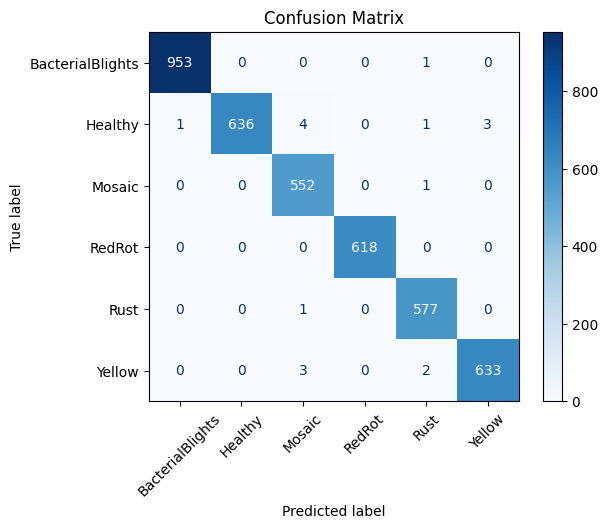

In [44]:
all_labels = []
all_preds = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

### Classification Report

In [36]:
print(classification_report(all_labels, all_preds, target_names=class_names))

                  precision    recall  f1-score   support

BacterialBlights       1.00      1.00      1.00       954
         Healthy       1.00      0.99      1.00       645
          Mosaic       0.99      1.00      0.99       553
          RedRot       1.00      1.00      1.00       618
            Rust       0.99      1.00      1.00       578
          Yellow       0.99      0.99      0.99       638

        accuracy                           1.00      3986
       macro avg       1.00      1.00      1.00      3986
    weighted avg       1.00      1.00      1.00      3986



### Per-Class Accuracy

In [37]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(class_names):
    print(f"{cls}: {class_accuracy[i]*100:.2f}%")

BacterialBlights: 100.00%
Healthy: 99.22%
Mosaic: 99.82%
RedRot: 99.51%
Rust: 99.83%
Yellow: 99.22%


### Accuracy Curves

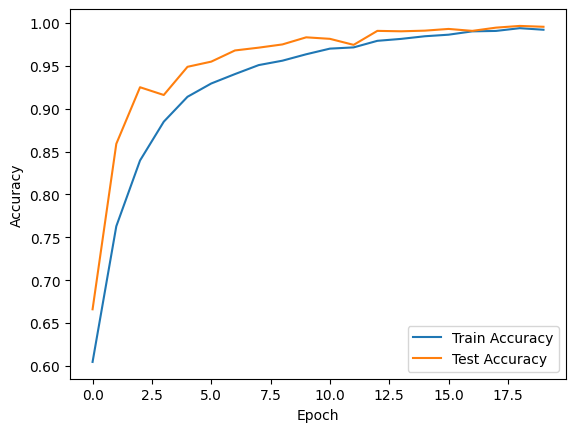

In [46]:
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(test_acc_history, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()